In [1]:
import os
import re
import string
import pickle
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [2]:
df=pd.read_csv("Amazon_reviews_2023.csv")

In [3]:
df


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True
...,...,...,...,...,...,...,...,...,...,...
701523,4,Four Stars,Conditioner is great shampoo not as I expected,[],B006YUIWKA,B006YUIWKA,AFIXGFVEGLMOTMBTJL7H3VSIETDQ,2016-11-04 02:37:01.000,0,True
701524,1,Pretty,Did not work! Used the whole bottle and my hai...,[],B006YUIWKA,B006YUIWKA,AFV7YZFOJF564EZGET5LG45K4QEA,2016-12-05 03:32:10.000,0,False
701525,5,Great sunless tanner,Product as expected. Shipping was on time.,[],B06ZZV9MZT,B06ZZV9MZT,AHYDCWDMMVMLBX7FY7M7JKADKRDQ,2020-05-27 02:52:54.067,0,True
701526,5,The Crown on top is a Ring!!!,"Not only is it a delicious fragrance, but also...",[],B000HB6VLE,B000HB6VLE,AF6ZIAEN7TQ2WY5ZL77F6JDPV7XQ,2007-07-18 22:36:49.000,4,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701528 entries, 0 to 701527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   rating             701528 non-null  int64 
 1   title              701368 non-null  object
 2   text               701316 non-null  object
 3   images             701528 non-null  object
 4   asin               701528 non-null  object
 5   parent_asin        701528 non-null  object
 6   user_id            701528 non-null  object
 7   timestamp          701528 non-null  object
 8   helpful_vote       701528 non-null  int64 
 9   verified_purchase  701528 non-null  bool  
dtypes: bool(1), int64(2), object(7)
memory usage: 48.8+ MB


In [72]:
df2=df.sample(10000)

# EDA

In [73]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 464952 to 89462
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   rating             10000 non-null  int64 
 1   title              9997 non-null   object
 2   text               9998 non-null   object
 3   images             10000 non-null  object
 4   asin               10000 non-null  object
 5   parent_asin        10000 non-null  object
 6   user_id            10000 non-null  object
 7   timestamp          10000 non-null  object
 8   helpful_vote       10000 non-null  int64 
 9   verified_purchase  10000 non-null  bool  
dtypes: bool(1), int64(2), object(7)
memory usage: 791.0+ KB


In [74]:
df2.drop(columns=['images','asin','timestamp','asin','parent_asin','verified_purchase'],inplace=True)

In [75]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 464952 to 89462
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rating        10000 non-null  int64 
 1   title         9997 non-null   object
 2   text          9998 non-null   object
 3   user_id       10000 non-null  object
 4   helpful_vote  10000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 468.8+ KB


In [76]:
df2.isnull().sum()

rating          0
title           3
text            2
user_id         0
helpful_vote    0
dtype: int64

In [77]:
df2.dropna(inplace=True)

In [78]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 464952 to 89462
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rating        9996 non-null   int64 
 1   title         9996 non-null   object
 2   text          9996 non-null   object
 3   user_id       9996 non-null   object
 4   helpful_vote  9996 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 468.6+ KB


In [79]:
df2[df2.duplicated()]

,rating,title,text,user_id,helpful_vote
697643,1,One Star,I received a damage item. It doesn't work.,AHIEU2QI5FKSJYL2ZY7IKU5GC5KQ,1
263991,5,Love it,Love this product. I have been using it for a ...,AGACBFIK53PBJVAZKRBYEO2ZWHRA,0


In [80]:
df2['rating'].value_counts()

rating
5    6062
1    1470
4    1109
3     789
2     566
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x173c07065d0>,
 [Text(-0.36102194940154775, 1.0390684058570476, ''),
  Text(-0.46853203296812557, -0.9952274785609346, ''),
  Text(0.398332833158696, -1.0253443099894624, ''),
  Text(0.9055392723998275, -0.6244986998718184, ''),
  Text(1.0826421767566923, -0.1946430504989359, '')],
 [Text(-0.1969210633099351, 0.566764585012935, '60.64'),
  Text(-0.255562927073523, -0.5428513519423279, '14.71'),
  Text(0.2172724544501978, -0.5592787145397067, '11.09'),
  Text(0.4939305122180876, -0.34063565447553723, '7.89'),
  Text(0.5905320964127412, -0.10616893663578321, '5.66')])

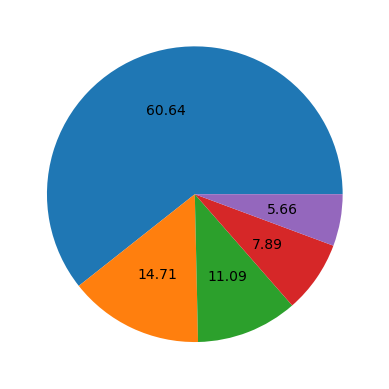

In [81]:
import matplotlib.pyplot as plt
plt.pie(df2['rating'].value_counts(),autopct="%0.2f")


### is Data is imbalanced

In [29]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [82]:
df2['num_characters']=df2['text'].apply(len)

In [36]:
df2.head()

,rating,title,text,user_id,helpful_vote,num_characters
524552,3,It was ok,The first bundle I ordered was perfect. I want...,AHWZFBS3YOJZBCJ3DAQJW5ITDLIA,0,201
365642,2,It's cheap and perfect for travel only.,It does heat up like my others do it only reac...,AGMXKDZBKUGGQAGYXKWCTBOWSGUA,1,296
283445,3,Super Cute Novelty,I bought this more because of all the cute pac...,AFVSWIHIHL6TOVCMTGO436JXMUDQ,4,418
485339,1,You get ripped off,The description say 2 PCs and I only received ...,AFALYZH4UTLVNVJ5UO3ZXERGSU6Q,0,89
493213,4,worth the price,I don't know much about weaves. But this bund...,AEGCLENOHBCD2HJCXDJCAGP3KECA,1,220


In [50]:
import nltk
import os

# Ensure correct path
nltk.data.path = [r"C:\Users\hp\AppData\Roaming\nltk_data"]

# Download the missing punkt_tab
nltk.download("punkt_tab", quiet=False)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [83]:
df2['text'].apply(lambda x:nltk.word_tokenize(x))

464952    [I, love, Sparkle, &, Co., products, !, I, use...
423754    [I, 've, never, had, shampoo, and, conditioner...
388390    [This, is, the, perfect, spray, bottle, ., I, ...
233680    [Although, it, is, for, a, brunette, it, was, ...
486827    [It, 's, a, no, ., tangles, and, sheds, like, ...
                                ...                        
358158    [I, have, had, so, many, different, types, and...
155316                               [First, time, to, use]
388812    [This, is, a, wonderful, product, ., My, skin,...
506200                                        [I, like, it]
89462      [Perfect, because, I, have, a, lot, of, hair, !]
Name: text, Length: 9996, dtype: object

In [84]:
df2['num_words']=df2['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [85]:
df2.head()

,rating,title,text,user_id,helpful_vote,num_characters,num_words
464952,5,Absolutely perfect peel base!,I love Sparkle & Co. products! I use this with...,AFTBPYMNG5IIGDTODBW6BQTDGE5A,2,533,123
423754,5,Best Shampoo and conditioner set,I've never had shampoo and conditioner that ma...,AG4L4QBNQXBBFRU7J442BE2UAKQA,0,294,63
388390,5,"Love, Love, Love!!",This is the perfect spray bottle. I absolutely...,AHGQ73H4IN6YBCETEHPTBMQTCW7A,0,131,30
233680,3,Brow liner,Although it is for a brunette it was much ligh...,AHFCVENXXRBA7Y7UY767K6MORB4A,0,70,13
486827,1,The naps!,It's a no. tangles and sheds like hell!,AFR42DL3RWLZIVEUCOR2AHYDATLQ,0,39,11


In [86]:
df2['num_sentences']=df2['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [87]:
df2.head()

,rating,title,text,user_id,helpful_vote,num_characters,num_words,num_sentences
464952,5,Absolutely perfect peel base!,I love Sparkle & Co. products! I use this with...,AFTBPYMNG5IIGDTODBW6BQTDGE5A,2,533,123,9
423754,5,Best Shampoo and conditioner set,I've never had shampoo and conditioner that ma...,AG4L4QBNQXBBFRU7J442BE2UAKQA,0,294,63,5
388390,5,"Love, Love, Love!!",This is the perfect spray bottle. I absolutely...,AHGQ73H4IN6YBCETEHPTBMQTCW7A,0,131,30,4
233680,3,Brow liner,Although it is for a brunette it was much ligh...,AHFCVENXXRBA7Y7UY767K6MORB4A,0,70,13,1
486827,1,The naps!,It's a no. tangles and sheds like hell!,AFR42DL3RWLZIVEUCOR2AHYDATLQ,0,39,11,2


In [88]:
df2[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,9996.000000,9996.000000,9996.000000
mean,173.165266,38.242597,2.818027
std,258.345098,57.322858,2.732752
min,1.000000,0.000000,0.000000
25%,44.000000,10.000000,1.000000
50%,101.000000,22.000000,2.000000
75%,205.000000,45.000000,4.000000
max,7033.000000,1609.000000,75.000000


In [60]:
# Recompute word count
df2['num_words'] = df2['text'].str.split().str.len()

# Keep only reviews with at least 3 words
before = len(df2)
df2 = df2[df2['num_words'] >= 3]
print(f"Removed {before - len(df2)} too-short reviews. Remaining: {len(df2)}")

Removed 719 too-short reviews. Remaining: 9277


In [89]:
MAX_WORDS = 300

def truncate(text):
    words = str(text).split()
    return " ".join(words[:MAX_WORDS])

df2['text'] = df2['text'].apply(truncate)
df2['num_words'] = df2['text'].str.split().str.len()
print("After truncation:")
print(df2['num_words'].describe())

After truncation:
count    9996.000000
mean       32.062225
std        40.898942
min         0.000000
25%         8.000000
50%        19.000000
75%        39.000000
max       300.000000
Name: num_words, dtype: float64


In [91]:
import pandas as pd

def to_label(r):
    if r >= 4: return "positive"
    if r == 3: return "neutral"
    return "negative"

df2['label'] = df2['rating'].apply(to_label)

print("\nClass distribution:")
print(df2['label'].value_counts())


Class distribution:
label
positive    7171
negative    2036
neutral      789
Name: count, dtype: int64


In [90]:
df2.dec

AttributeError: 'DataFrame' object has no attribute 'dec'

In [64]:
# ============================================================
# Balance classes: undersample majority + oversample minority
# ============================================================

import pandas as pd

TARGET = 2000   # har class me ~2000 samples

def balance_classes(df, target_per_class):
    balanced_parts = []

    for label in df['label'].unique():
        subset = df[df['label'] == label]

        if len(subset) >= target_per_class:
            # Undersample
            part = subset.sample(target_per_class, random_state=42)
        else:
            # Oversample (with replacement)
            part = subset.sample(target_per_class, replace=True, random_state=42)

        balanced_parts.append(part)

    return pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)

df_balanced = balance_classes(df2, TARGET)

print("Balanced class distribution:")
print(df_balanced['label'].value_counts())
print("\nTotal rows:", len(df_balanced))

df_balanced.to_csv("reviews_balanced.csv", index=False)
print("✅ Saved reviews_balanced.csv")

Balanced class distribution:
label
neutral     2000
negative    2000
positive    2000
Name: count, dtype: int64

Total rows: 6000
✅ Saved reviews_balanced.csv


In [65]:
# ============================================================
# Step 5 — Text Preprocessing
# ============================================================
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Ensure NLTK data
nltk.data.path = [r"C:\Users\hp\AppData\Roaming\nltk_data"]
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)       # keep only letters + spaces
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

# Load balanced dataset
import pandas as pd
df_balanced = pd.read_csv("reviews_balanced.csv")

df_balanced["clean_text"] = df_balanced["text"].apply(preprocess)

# Show sample
print("Raw   :", df_balanced["text"].iloc[0][:120])
print("Clean :", df_balanced["clean_text"].iloc[0][:120])
print("\n✅ Preprocessing done")

Raw   : These cloths are not soft like the pink package
Clean : cloth soft like pink packag

✅ Preprocessing done


In [66]:
# ============================================================
# Step 6 — Train/Test Split (80/20 stratified)
# ============================================================
from sklearn.model_selection import train_test_split

X = df_balanced["clean_text"]
y = df_balanced["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train size: {len(X_train)}")
print(f"Test  size: {len(X_test)}")
print("\nTrain distribution:")
print(y_train.value_counts())
print("\nTest distribution:")
print(y_test.value_counts())
print("\n✅ Split done")

Train size: 4800
Test  size: 1200

Train distribution:
label
positive    1600
neutral     1600
negative    1600
Name: count, dtype: int64

Test distribution:
label
negative    400
positive    400
neutral     400
Name: count, dtype: int64

✅ Split done


In [67]:
# ============================================================
# Step 7 — TF-IDF Vectorization
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=1,
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Train matrix  :", X_train_vec.shape)
print("Test  matrix  :", X_test_vec.shape)
print("\n✅ Vectorization done")

Vocabulary size: 5000
Train matrix  : (4800, 5000)
Test  matrix  : (1200, 5000)

✅ Vectorization done


In [68]:
# ============================================================
# Step 8 — Train Multinomial Naive Bayes + Evaluate
# ============================================================
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

# Train
model = MultinomialNB(alpha=1.0)
model.fit(X_train_vec, y_train)
print("✅ Model trained\n")

# Predict
y_pred = model.predict(X_test_vec)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Accuracy   : {acc:.4f}")
print(f"Precision  : {prec:.4f}")
print(f"Recall     : {rec:.4f}")
print(f"F1 (macro) : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=["positive", "neutral", "negative"]))

✅ Model trained

Accuracy   : 0.7525
Precision  : 0.7642
Recall     : 0.7525
F1 (macro) : 0.7501

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.78      0.76       400
     neutral       0.85      0.62      0.72       400
    positive       0.71      0.85      0.77       400

    accuracy                           0.75      1200
   macro avg       0.76      0.75      0.75      1200
weighted avg       0.76      0.75      0.75      1200

Confusion Matrix:
[[342  18  40]
 [ 80 249  71]
 [ 61  27 312]]


In [69]:
# ============================================================
# Step 9 — Save model artifacts for Flask backend
# ============================================================
import os
import pickle

os.makedirs("ml_artifacts", exist_ok=True)

with open("ml_artifacts/model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("ml_artifacts/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("✅ Saved ml_artifacts/model.pkl")
print("✅ Saved ml_artifacts/vectorizer.pkl")

✅ Saved ml_artifacts/model.pkl
✅ Saved ml_artifacts/vectorizer.pkl


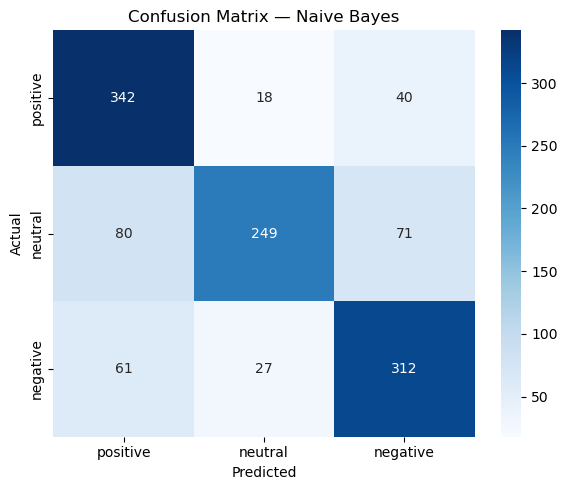

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=["positive", "neutral", "negative"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["positive", "neutral", "negative"],
    yticklabels=["positive", "neutral", "negative"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Naive Bayes")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [71]:
# ============================================================
# Step 10 — Test on custom reviews
# ============================================================
def quick_predict(text):
    clean = preprocess(text)
    vec = vectorizer.transform([clean])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0].max()
    return pred, round(float(proba), 3)

samples = [
    "Best headphones I have ever used, sound quality is amazing!",
    "It is okay, works as expected but nothing special.",
    "Stopped working after two days, total waste of money.",
    "Absolutely love this laptop, super fast and great battery.",
]

for s in samples:
    label, conf = quick_predict(s)
    print(f"[{label:8s}] {conf:.2f} — {s}")

[positive] 0.79 — Best headphones I have ever used, sound quality is amazing!
[neutral ] 0.51 — It is okay, works as expected but nothing special.
[negative] 0.94 — Stopped working after two days, total waste of money.
[positive] 0.91 — Absolutely love this laptop, super fast and great battery.


In [92]:
# ============================================================
# Improved pipeline
# ============================================================
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# --- Negation handling ---
def handle_negations(tokens):
    result, i = [], 0
    while i < len(tokens):
        if tokens[i] in ("not", "no", "never") and i + 1 < len(tokens):
            result.append(f"NOT_{tokens[i+1]}")
            i += 2
        else:
            result.append(tokens[i])
            i += 1
    return result

# --- Better preprocess ---
def preprocess_v2(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = handle_negations(tokens)
    return " ".join(tokens)

# Apply
df_balanced["clean_text"] = df_balanced["text"].apply(preprocess_v2)

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced["clean_text"], df_balanced["label"],
    test_size=0.2, random_state=42, stratify=df_balanced["label"],
)

# --- Better TF-IDF ---
vectorizer_v2 = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)
X_train_vec_v2 = vectorizer_v2.fit_transform(X_train)
X_test_vec_v2  = vectorizer_v2.transform(X_test)

# --- Compare models ---
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "NB (alpha=0.1)":   MultinomialNB(alpha=0.1),
    "NB (alpha=0.3)":   MultinomialNB(alpha=0.3),
    "Logistic Reg":     LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced"),
    "Logistic Reg C=2": LogisticRegression(C=2.0, max_iter=1000, class_weight="balanced"),
    "Linear SVM":       LinearSVC(C=1.0, class_weight="balanced", max_iter=2000),
}

print(f"{'Model':<20}  Accuracy")
print("-" * 35)
for name, m in models.items():
    m.fit(X_train_vec_v2, y_train)
    acc = m.score(X_test_vec_v2, y_test)
    print(f"{name:<20}  {acc:.4f}")

Model                 Accuracy
-----------------------------------
NB (alpha=0.1)        0.7917
NB (alpha=0.3)        0.7775
Logistic Reg          0.8217
Logistic Reg C=2      0.8458
Linear SVM            0.8575


In [93]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

best_model = LinearSVC(C=1.0, class_weight="balanced", max_iter=2000)
best_model.fit(X_train_vec_v2, y_train)

y_pred = best_model.predict(X_test_vec_v2)

print("Accuracy :", round(best_model.score(X_test_vec_v2, y_test), 4))
print("F1 macro :", round(f1_score(y_test, y_pred, average="macro"), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=["positive", "neutral", "negative"]))

Accuracy : 0.8575
F1 macro : 0.8573

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.86      0.86       400
     neutral       0.86      0.89      0.87       400
    positive       0.86      0.82      0.84       400

    accuracy                           0.86      1200
   macro avg       0.86      0.86      0.86      1200
weighted avg       0.86      0.86      0.86      1200

Confusion Matrix:
[[330  33  37]
 [ 25 356  19]
 [ 30  27 343]]


In [94]:
# ============================================================
# Experiment 1 — Tune LinearSVC
# ============================================================
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

results = []

# Try different C values
for C in [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]:
    m = LinearSVC(C=C, class_weight="balanced", max_iter=3000)
    m.fit(X_train_vec_v2, y_train)
    pred = m.predict(X_test_vec_v2)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    results.append(("C=%.1f" % C, acc, f1))
    print(f"C={C:<4}  acc={acc:.4f}  f1={f1:.4f}")

# Try class_weight variations
for cw_name, cw in [
    ("balanced", "balanced"),
    ("pos_heavy", {0:1.0, 1:1.0, 2:1.3}),   # positive gets more weight
    ("neg_heavy", {0:1.3, 1:1.0, 2:1.0}),   # negative gets more weight
    ("neu_heavy", {0:1.0, 1:1.3, 2:1.0}),   # neutral gets more weight
]:
    m = LinearSVC(C=1.5, class_weight=cw, max_iter=3000)
    m.fit(X_train_vec_v2, y_train)
    pred = m.predict(X_test_vec_v2)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    results.append((cw_name, acc, f1))
    print(f"{cw_name:<10}  acc={acc:.4f}  f1={f1:.4f}")

# Best
best = max(results, key=lambda x: x[1])
print(f"\n🏆 Best: {best[0]}  acc={best[1]:.4f}  f1={best[2]:.4f}")

C=0.5   acc=0.8550  f1=0.8549
C=1.0   acc=0.8575  f1=0.8573
C=1.5   acc=0.8592  f1=0.8589
C=2.0   acc=0.8550  f1=0.8547
C=3.0   acc=0.8542  f1=0.8538
C=5.0   acc=0.8483  f1=0.8479
balanced    acc=0.8592  f1=0.8589


ValueError: The classes, ['negative', 'neutral', 'positive'], are not in class_weight

In [95]:
# ============================================================
# Experiment 1 — Tune LinearSVC
# ============================================================
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

results = []

# Try different C values
for C in [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]:
    m = LinearSVC(C=C, class_weight="balanced", max_iter=3000)
    m.fit(X_train_vec_v2, y_train)
    pred = m.predict(X_test_vec_v2)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    results.append(("C=%.1f" % C, acc, f1))
    print(f"C={C:<4}  acc={acc:.4f}  f1={f1:.4f}")

print()

# Try class_weight variations (STRING keys!)
for cw_name, cw in [
    ("balanced",   "balanced"),
    ("pos_heavy",  {"negative": 1.0, "neutral": 1.0, "positive": 1.3}),
    ("neg_heavy",  {"negative": 1.3, "neutral": 1.0, "positive": 1.0}),
    ("neu_heavy",  {"negative": 1.0, "neutral": 1.3, "positive": 1.0}),
]:
    m = LinearSVC(C=1.5, class_weight=cw, max_iter=3000)
    m.fit(X_train_vec_v2, y_train)
    pred = m.predict(X_test_vec_v2)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    results.append((cw_name, acc, f1))
    print(f"{cw_name:<10}  acc={acc:.4f}  f1={f1:.4f}")

# Best
best = max(results, key=lambda x: x[1])
print(f"\n🏆 Best: {best[0]}  acc={best[1]:.4f}  f1={best[2]:.4f}")

C=0.5   acc=0.8550  f1=0.8549
C=1.0   acc=0.8575  f1=0.8573
C=1.5   acc=0.8592  f1=0.8589
C=2.0   acc=0.8550  f1=0.8547
C=3.0   acc=0.8542  f1=0.8538
C=5.0   acc=0.8483  f1=0.8479

balanced    acc=0.8592  f1=0.8589
pos_heavy   acc=0.8625  f1=0.8624
neg_heavy   acc=0.8558  f1=0.8554
neu_heavy   acc=0.8592  f1=0.8588

🏆 Best: pos_heavy  acc=0.8625  f1=0.8624


In [96]:
# ============================================================
# Experiment 2 — Combined word + char TF-IDF + best SVM
# ============================================================
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Build combined vectorizer
combined_vec = FeatureUnion([
    ("word", TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 3),
        max_features=15000,
        min_df=2,
        sublinear_tf=True,
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=10000,
        min_df=3,
        sublinear_tf=True,
    )),
])

# Fit on train, transform both
X_train_c = combined_vec.fit_transform(X_train)
X_test_c  = combined_vec.transform(X_test)

print("Feature shape:", X_train_c.shape)

# Train with the BEST settings found earlier
best_clf = LinearSVC(
    C=1.5,
    class_weight={"negative": 1.0, "neutral": 1.0, "positive": 1.3},
    max_iter=3000,
)
best_clf.fit(X_train_c, y_train)
pred_c = best_clf.predict(X_test_c)

acc = accuracy_score(y_test, pred_c)
f1  = f1_score(y_test, pred_c, average="macro")

print(f"\nAccuracy: {acc:.4f}")
print(f"F1 macro: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pred_c, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_c, labels=["positive", "neutral", "negative"]))

Feature shape: (4800, 25000)

Accuracy: 0.8617
F1 macro: 0.8615

Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.85      0.86       400
     neutral       0.86      0.90      0.88       400
    positive       0.86      0.83      0.85       400

    accuracy                           0.86      1200
   macro avg       0.86      0.86      0.86      1200
weighted avg       0.86      0.86      0.86      1200

Confusion Matrix:
[[334  30  36]
 [ 23 358  19]
 [ 32  26 342]]


In [97]:
# ============================================================
# Save final model + vectorizer for Flask backend
# ============================================================
import os, pickle

os.makedirs("ml_artifacts", exist_ok=True)

# Final model — LinearSVC with best settings found
final_model = LinearSVC(
    C=1.5,
    class_weight={"negative": 1.0, "neutral": 1.0, "positive": 1.3},
    max_iter=3000,
)
final_model.fit(X_train_vec_v2, y_train)

# Save
with open("ml_artifacts/model.pkl", "wb") as f:
    pickle.dump(final_model, f)
with open("ml_artifacts/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer_v2, f)

# Verify
print("Saved files:")
for f in os.listdir("ml_artifacts"):
    size = os.path.getsize(f"ml_artifacts/{f}") / 1024
    print(f"  {f}  ({size:.1f} KB)")

print(f"\nTest accuracy: {final_model.score(X_test_vec_v2, y_test):.4f}")

Saved files:
  model.pkl  (235.1 KB)
  vectorizer.pkl  (392.9 KB)

Test accuracy: 0.8625
